In [1]:
import aopy
from aopy.data import db
from aopy.analysis import accllr
import os
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
import h5py
import traceback
from scipy.stats import zscore
import datetime
from tqdm.auto import tqdm
from IPython.display import display, Markdown
import pandas as pd
import seaborn as sns
from scipy.optimize import curve_fit
from matplotlib.gridspec import GridSpec

from aopy.visualization import annotate_spatial_map_channels
from aopy.data.bmi3d import tabulate_ts_data
from aopy.preproc.bmi3d import get_laser_trial_times
from aopy.preproc.quality import detect_bad_trials

from aopy.analysis.connectivity import get_acq_ch_near_stimulation_site
from aopy.visualization import plot_xy_scalebar, overlay_sulci_on_spatial_map
from aopy.visualization import plot_annotated_spatial_drive_map_stim, plot_annotated_stim_drive_data
from aopy.analysis import calc_fdrc_ranktest

data_dir = '/media/moor-data/raw'
preproc_dir = '/media/moor-data/preprocessed'
postproc_dir = '/data/postprocessed/leo'
fig_dir = './figures'

version = 'v260218'


/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [2]:
sns.set_theme('paper', font_scale=1, font="Arial", rc={
    'svg.fonttype': 'none',
    "font.size" : 10,
    "axes.labelsize" : 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})
%config InlineBackend.print_figure_kwargs = {'bbox_inches':None}

In [3]:
from connectivity_analysis import *
from connectivity_plotting import *

In [4]:
elec_pos, acq_ch, elecs = aopy.data.load_chmap()

## Load data

In [5]:
a_rest_df = load_df(postproc_dir, 'affi', 'rest', version)
b_rest_df = load_df(postproc_dir, 'beignet', 'rest', version)
a_null_df = load_df(postproc_dir, 'affi', 'rest_null', version)
b_null_df = load_df(postproc_dir, 'beignet', 'rest_null', version)

  0%|          | 0/32 [00:00<?, ?it/s]

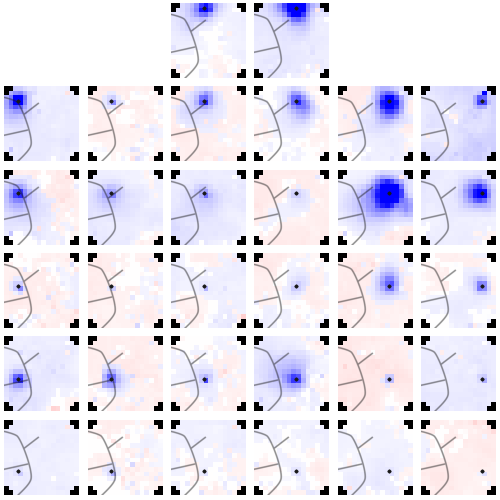

  0%|          | 0/32 [00:00<?, ?it/s]

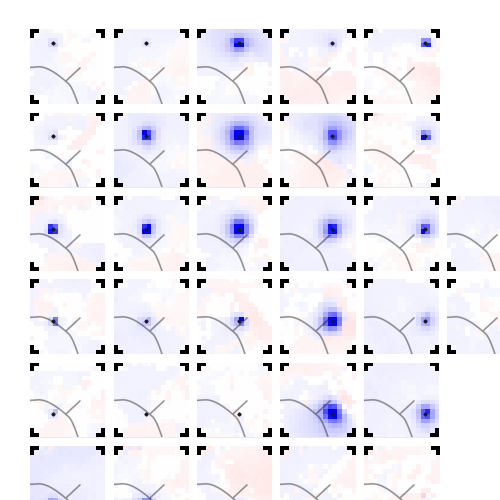

In [195]:
alpha = 0.05
for subject in ['beignet', 'affi']:
    
    subj_data = aopy.data.pkl_read(
        f'{subject}_connectivity_all_sites_{version}.pkl', postproc_dir)
    theta = 0 if subject == 'beignet' else 90
    stim_ch = subj_data['sites']
    
    elec_pos, acq_ch, elecs = aopy.data.load_chmap(theta=theta)
    fig1, ax_data = place_Opto32_subplots(theta=theta)

    for idx, stim_site in enumerate(tqdm(stim_ch)):

        diff, p = calc_fdrc_ranktest(subj_data['erp_map'][idx], subj_data['erp_null_maps'][idx], 
                                     alternative='two-sided', alpha=alpha)
        scaled = scale_data_by_p_value(subj_data['erp_map'][idx], p)
                
        # Plot the data
        plot_annotated_spatial_drive_map_stim(scaled, stim_site, subject, 'lm1', theta, 
                                              cmap='bwr', clim=(-3,3), interp_method='cubic', 
                                              colorbar=False, color='k', ax=ax_data[idx])        
    filename = f"opto_response_all_{subject}.svg"
    aopy.visualization.savefig(fig_dir, filename)
    plt.show()



## Plot examples

In [6]:
b_all_sites = aopy.data.pkl_read(
    f'beignet_connectivity_all_sites_{version}.pkl', postproc_dir)
a_all_sites = aopy.data.pkl_read(
    f'affi_connectivity_all_sites_{version}.pkl', postproc_dir)

In [10]:
# Example ERP
stim_site = 12
subject = 'beignet'
theta = 0
alpha = 0.05

time_before = 0.25
time_after = 0.25
altcond_window = (0, 0.05)
nullcond_window = (-time_before, 0)

df = b_rest_df[b_rest_df['stimulation_site'].astype(int) == stim_site].reset_index()
bad_trials = get_bad_stim_trials(df, time_before, time_after, channels=acq_ch-1)
df = df[~bad_trials].reset_index()

erp, samplerate = load_stim_erp(df, time_before, time_after, channels=acq_ch-1)

altcond, nullcond = aopy.analysis.latency.prepare_erp(erp, erp, samplerate, 
                                                      time_before, time_after, 
                                                      nullcond_window, altcond_window)[:2]

# Max ERP
z_erp = np.std(nullcond, axis=0)
sd_erp = (altcond - np.mean(nullcond, axis=0)) / z_erp
max_erp = aopy.analysis.get_max_erp(sd_erp, 0, time_after, samplerate, trial_average=True)

ch_stim = 39
ch_near = 54
ch_far = 127
idx_stim = np.where(acq_ch == ch_stim)[0][0]
idx_near = np.where(acq_ch == ch_near)[0][0]
idx_far = np.where(acq_ch == ch_far)[0][0]

# Single trial ERP
erp_trials = sd_erp[:,idx_stim,:]
erp_surround = sd_erp[:,idx_near,:]
erp_control = sd_erp[:,idx_far,:]

In [11]:
# Latency
altcond_window_accllr = (0, 0.06)
nullcond_window_accllr = (-0.06, 0)
altcond, nullcond = aopy.analysis.latency.prepare_erp(erp, erp, samplerate, 
                                                      time_before, time_after, 
                                                      nullcond_window_accllr, altcond_window_accllr)[:2]

st, auc, se, p = aopy.analysis.latency.calc_accllr_st(
    altcond, nullcond, 
    altcond, nullcond,
    'lfp', 1./samplerate, nlevels=None, match_selectivity=False, 
    match_ch=None, noise_sd_step=5, parallel=True
)

latency = np.nanmedian(st, axis=1)
latency_trials = st[idx_stim,:]
latency_surround = st[idx_near,:]
latency_control = st[idx_far,:]

  0%|          | 0/240 [00:00<?, ?it/s]

/tmp/ipykernel_4138929/908681979.py:15: RuntimeWarning: All-NaN slice encountered
  latency = np.nanmedian(st, axis=1)


In [12]:
# AUC Monkey 1
b_volume, p = calc_volume(b_all_sites['erp_map'], b_all_sites['erp_null_maps'], alpha=alpha)
b_volume[p > alpha] = np.nan

# AUC Monkey 2
a_volume, p = calc_volume(a_all_sites['erp_map'], a_all_sites['erp_null_maps'], alpha=alpha)
a_volume[p > alpha] = np.nan

In [13]:
def plot_electrode_selection(selected_idx, unselected_idx, elec_pos, color='black', 
                             ax=None, **kwargs):
    """
    Draws boxes around selected electrodes at the given electrode positions.

    Parameters:

    - channels_pos: numpy array of shape (n_channels, 2) with the positions of the electrodes.
    - selected_electrodes: list or array of indices of the selected electrodes.
    - ax: matplotlib axes object where the plot will be drawn. If None, a new figure and axes will be created.
    """
    if ax is None:
        ax = plt.gca()
        
    # Plot the selected electrodes using a solid square
    ax.plot(elec_pos[selected_idx, 0], 
            elec_pos[selected_idx, 1], "s", 
            c=color,
            **kwargs)

    # Plot the unselected electrodes using a hollow square
    ax.plot(elec_pos[unselected_idx, 0], 
            elec_pos[unselected_idx, 1], "s",
            c=color,
            markerfacecolor='none',
            markeredgecolor=color,
            **kwargs)

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_aspect('equal')

    # Remove the plot boundary
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # Remove the x and y scale markers
    ax.set_xticks([])
    ax.set_yticks([])


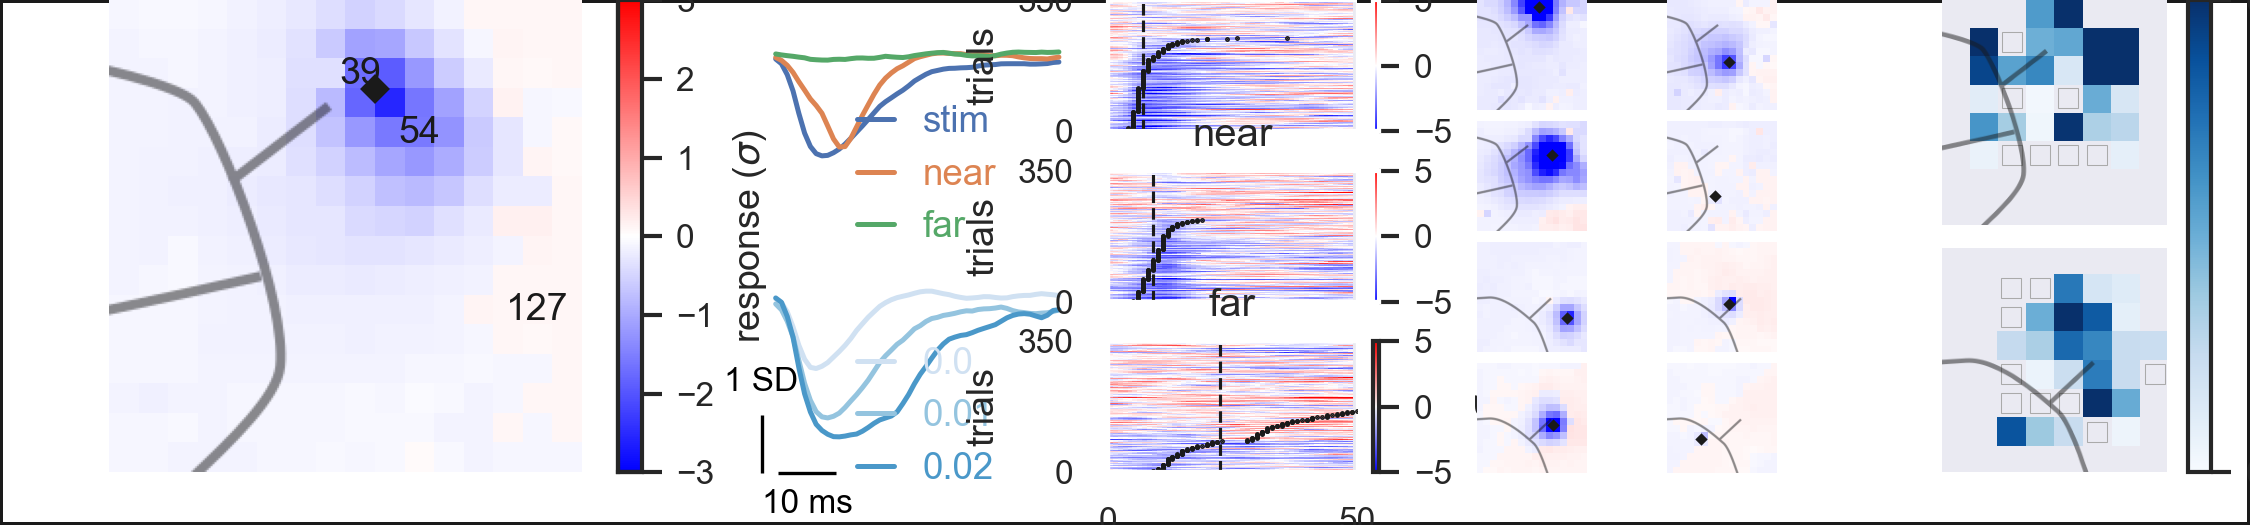

In [14]:
# Figure 1 plots

fig = plt.figure(figsize=(7.5, 1.75), dpi=300, edgecolor='k', linewidth=1)
wr = [0.35, 0.15, 0.15, 0.075, 0.075, 0.2]
grid2 = GridSpec(2, 6, width_ratios=wr, wspace=0.1, hspace=0.1)
grid3 = GridSpec(3, 6, width_ratios=wr, wspace=0.1, hspace=0.3)
grid4 = GridSpec(4, 6, width_ratios=wr, wspace=0.1, hspace=0.1)
plt.subplots_adjust(left=0, right=1, top=1, bottom=0.1)

sns.set_style('ticks') 
ax = fig.add_subplot(grid2[:,0])
im, pcm = plot_annotated_spatial_drive_map_stim(max_erp, stim_site, df['subject'][0], 'lm1', 0, 
                                           grid_size=(16,16), cmap='bwr', clim=(-3,3),
                                           colorbar=True, fontsize=9, color='k')
aopy.visualization.annotate_spatial_map_channels(acq_ch=[ch_stim, ch_near, ch_far],
                                                 color='k', fontsize=9)        
pcm.set_label('response ($\\sigma$)')
plt.axis('off')

# Sweep recording electrode
sns.set_style('darkgrid') 
ax = fig.add_subplot(grid4[:2,1])

aopy.visualization.plot_timeseries(np.mean(erp_trials, axis=1), samplerate)
aopy.visualization.plot_timeseries(np.mean(erp_surround, axis=1), samplerate)
aopy.visualization.plot_timeseries(np.mean(erp_control, axis=1), samplerate)
plt.ylim(-3,1)
plt.legend(['stim', 'near', 'far'], bbox_to_anchor=(0.2,-0.2), loc='lower left', 
           labelcolor='linecolor', handlelength=1, frameon=False)
plt.axis('off')

# Sweep pulse width
ax = fig.add_subplot(grid4[2:,1])
colors = sns.color_palette('Blues', n_colors=4)
ax.set_prop_cycle(plt.cycler(color=colors))
width = np.round(df['trial_width'], 2)
widths = np.unique(width)
for w in widths:
    aopy.visualization.plot_timeseries(np.mean(erp_trials[:,width==w], axis=1), samplerate)
plt.ylim(-3,1)
plt.legend(widths, bbox_to_anchor=(0.2,-0.2), loc='lower left', 
           labelcolor='linecolor', handlelength=1, frameon=False)
plt.axis('off')
plot_xy_scalebar(plt.gca(), 0.01, '10 ms', 1, '1 SD', color='black', fontsize=8,
                bbox_to_anchor=[0.,0.])


# Single trial response
ax = fig.add_subplot(grid3[0,2])
im = plot_stim_erp_time(erp_trials, -altcond_window[0], altcond_window[1], samplerate, stim_site, 
                   df['subject'][0], theta=0, clim=(-5,5), latency=latency_trials)
plt.xticks([0,50], labels=[])
sns.despine()
plt.colorbar(im)
plt.title('stim')
ax = fig.add_subplot(grid3[1,2])
im = plot_stim_erp_time(erp_surround, -altcond_window[0], altcond_window[1], samplerate, stim_site, 
                   df['subject'][0], theta=0, clim=(-5,5), latency=latency_surround)
plt.xticks([0,50], labels=[])
sns.despine()
tmp = plt.colorbar(im)
plt.title('near')
ax = fig.add_subplot(grid3[2,2])
im = plot_stim_erp_time(erp_control, -altcond_window[0], altcond_window[1], samplerate, stim_site, 
                        df['subject'][0], theta=0, clim=(-5,5), latency=latency_control)
plt.xlabel('time (ms)')
sns.despine()
sns.set_style('ticks') 
pcm = plt.colorbar(im)
pcm.set_label('$\\sigma$')
plt.title('far')


# Example big response sites
sns.set_style('ticks') 
for idx, (subject_, theta_, stim_site_) in enumerate(zip(
    ['beignet', 'beignet', 'affi', 'affi'], [0, 0, 90, 90], [11, 7, 6, 13])):
    
    ax = fig.add_subplot(grid4[idx,3]).axis('off')
    
    subj_connectivity = aopy.data.pkl_read(
        f'{subject_}_connectivity_all_sites_{version}.pkl', postproc_dir)
    max_erp_ = subj_connectivity['erp_map'][stim_site_-1]
    im = plot_annotated_spatial_drive_map_stim(max_erp_, stim_site_, subject_, 'lm1', theta_, 
                                               grid_size=(16,16), cmap='bwr', clim=(-3,3),
                                               colorbar=False, fontsize=9, color='k')

# Example small response sites
for idx, (subject_, theta_, stim_site_) in enumerate(zip(
    ['beignet', 'beignet', 'affi', 'affi'], [0, 0, 90, 90], [15, 22, 14, 10])):
    
    ax = fig.add_subplot(grid4[idx,4]).axis('off')
    
    subj_connectivity = aopy.data.pkl_read(
        f'{subject_}_connectivity_all_sites_{version}.pkl', postproc_dir)
    max_erp_ = subj_connectivity['erp_map'][stim_site_-1]
    im = plot_annotated_spatial_drive_map_stim(max_erp_, stim_site_, subject_, 'lm1', theta_, 
                                               grid_size=(16,16), cmap='bwr', clim=(-3,3),
                                               colorbar=False, fontsize=9, color='k')

# Plot significant AUC
# Monkey 1
ax1 = fig.add_subplot(grid2[0,5])
ax1.set_facecolor('#EAEAF2')
stim_pos, _, stim_ch = aopy.data.load_chmap('Opto32', theta=0)
plot_electrode_selection([], range(32), stim_pos, color='#AAAAAA', zorder=-1, markeredgewidth=0.25)
im, pcm = plot_annotated_stim_drive_data(b_volume, 'beignet', 'lm1', 0, cmap='Blues', nan_color="#00000000",
                                        colorbar=False)
im.set_clim(0,0.2)
plt.gca().set(xticks=[], yticks=[], xlabel='', ylabel='')

# Monkey 2
ax2 = fig.add_subplot(grid2[1,5])
ax2.set_facecolor('#EAEAF2')
stim_pos, _, stim_ch = aopy.data.load_chmap('Opto32', theta=90)
plot_electrode_selection([], range(32), stim_pos, color='#AAAAAA', zorder=-1, markeredgewidth=0.25)
im, pcm = plot_annotated_stim_drive_data(a_volume, 'affi', 'lm1', 90, cmap='Blues', nan_color="#00000000",
                                        colorbar=False)
im.set_clim(0,0.2)
plt.gca().set(xticks=[], yticks=[], xlabel='', ylabel='')

pcm = plt.colorbar(im, ax=[ax1, ax2])
pcm.set_ticks([0,0.2])
pcm.set_label('mean response ($\\sigma$)')

filename = f"opto_summary.svg"
aopy.visualization.savefig(fig_dir, filename)

## In-text statistics

In [24]:
# correlate pulse width to stimulation evoked amplitude
df_pw = None
alpha = 0.01
time_before = 0.25
time_after = 0.25
_, _, stim_sites = aopy.data.load_chmap('Opto32')
elec_pos, acq_ch, _ = aopy.data.load_chmap()
for subject in ['beignet', 'affi']:
    df_subj = load_df(postproc_dir, subject, 'rest', version)   
    
    for idx, stim_site in enumerate(tqdm(stim_sites)):

        # Subselect trials 
        df = df_subj[df_subj['stimulation_site'].astype(int) == stim_site].reset_index()

        # Subselect channels around stim site
        stim_ch = get_acq_ch_near_stimulation_site(stim_site)        
        print(f"{len(df)} trials for site {stim_site}")

        bad_trials = get_bad_stim_trials(df, channels=stim_ch-1, debug=False)
        # print(f"removed {np.sum(bad_trials)} bad trials")
        erp, samplerate = load_stim_erp(df[~bad_trials].reset_index(drop=True), 
                                        time_before, time_after, channels=stim_ch-1)
        width = 1000*np.round(df['trial_width'][~bad_trials], 3)

        altcond_window = (0, time_after)
        nullcond_window = (-time_before, 0)
        altcond, nullcond = aopy.analysis.latency.prepare_erp(erp, erp, samplerate, 
                                                              time_before, time_after, 
                                                              nullcond_window, altcond_window)[:2]

        z_erp = np.std(nullcond, axis=0)
        sd_erp = (altcond - np.mean(nullcond, axis=0)) / z_erp
        max_erp = aopy.analysis.get_max_erp(sd_erp, 0, time_after, samplerate, trial_average=False)
        max_erp = np.mean(max_erp, axis=0) # average across electrodes
        
        df_pw = pd.concat((df_pw, pd.DataFrame({'subject': subject, 'stim_site': stim_site, 'max_erp': max_erp, 'width': width})))

  0%|          | 0/32 [00:00<?, ?it/s]

354 trials for site 1
350 trials for site 2
352 trials for site 3
351 trials for site 4
359 trials for site 5
351 trials for site 6
351 trials for site 7
350 trials for site 8
350 trials for site 9
352 trials for site 10
351 trials for site 11
350 trials for site 12
351 trials for site 13
356 trials for site 14
350 trials for site 15
350 trials for site 16
350 trials for site 17
354 trials for site 18
353 trials for site 19
352 trials for site 20
350 trials for site 21
352 trials for site 22
350 trials for site 23
351 trials for site 24
351 trials for site 25
350 trials for site 26
352 trials for site 27
350 trials for site 28
351 trials for site 29
352 trials for site 30
350 trials for site 31
350 trials for site 32


  0%|          | 0/32 [00:00<?, ?it/s]

600 trials for site 1
600 trials for site 2
599 trials for site 3
600 trials for site 4
592 trials for site 5
600 trials for site 6
600 trials for site 7
600 trials for site 8
600 trials for site 9
600 trials for site 10
600 trials for site 11
600 trials for site 12
600 trials for site 13
600 trials for site 14
600 trials for site 15
600 trials for site 16
600 trials for site 17
600 trials for site 18
600 trials for site 19
600 trials for site 20
600 trials for site 21
600 trials for site 22
600 trials for site 23
600 trials for site 24
600 trials for site 25
600 trials for site 26
600 trials for site 27
600 trials for site 28
600 trials for site 29
600 trials for site 30
600 trials for site 31
600 trials for site 32


In [25]:
def corr_plot(df, x, y, x_bins=10):
    plt.figure(figsize=(3,2))
    colors = [color_monkey_1, color_monkey_2]
    plt.gca().set_prop_cycle(color=colors)
    df_1 = df[df["subject"] == "beignet"]
    df_2 = df[df["subject"] == "affi"]

    sns.regplot(data=df_1, x=x, y=y, x_bins=x_bins, scatter_kws={"s": 8})
    sns.regplot(data=df_2, x=x, y=y, x_bins=x_bins, marker="s", scatter_kws={"s": 8})
    import scipy
    _, _, r1, p1, _ = scipy.stats.linregress(x=df_1[x], y=df_1[y], nan_policy='omit')
    _, _, r2, p2, _ = scipy.stats.linregress(x=df_2[x], y=df_2[y], nan_policy='omit')
    plt.text(0.1, 0.1, f'$r = {np.round(r1,3)}, p = {np.round(p1,3)}$', 
             transform=plt.gca().transAxes, color=color_monkey_1, fontsize=9)
    plt.text(0.1, 0.25, f'$r = {np.round(r2,3)}, p = {np.round(p2,3)}$', 
             transform=plt.gca().transAxes, color=color_monkey_2, fontsize=9)
    print('b r=', np.round(r1,3), 'p=', np.round(p1,3), 'n =', np.count_nonzero(~np.isnan(df_1[y])))
    print('a r=', np.round(r2,3), 'p=', np.round(p2,3), 'n =', np.count_nonzero(~np.isnan(df_2[y])))
    sns.despine()
    plt.tight_layout()

b r= -0.137 p= 0.0 n = 11204
a r= -0.417 p= 0.0 n = 19130


(0.0, 101.0)

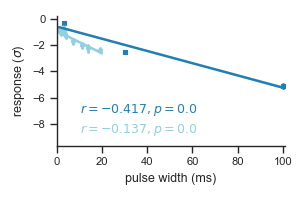

In [26]:
corr_plot(df_pw, x="width", y="max_erp")
plt.xlabel('pulse width (ms)')
plt.ylabel('response ($\\sigma$)')
plt.xlim(0, 101)

In [19]:
# correlate electrode distance to stimulation evoked amplitude
df_dist = None
for subject in ['beignet', 'affi']:
    
    subj_data = aopy.data.pkl_read(
        f'{subject}_connectivity_all_sites_{version}.pkl', postproc_dir)
    elec_pos, acq_ch, elecs = aopy.data.load_chmap(theta=0)
    stim_pos, _, stim_sites = aopy.data.load_chmap('Opto32', theta=0)
    volume, p = calc_volume(subj_data['erp_map'], subj_data['erp_null_maps'])

    for stim_site in tqdm(stim_sites):

        pos = stim_pos[np.where(stim_sites == stim_site)[0][0]]
        dist = [np.linalg.norm(np.array(p) - pos) for p in elec_pos]
        idx = stim_site - 1
        
        df_dist = pd.concat([df_dist, pd.DataFrame({
            'subject': subject,
            'stim_site': stim_site,
            'erp': subj_data['erp_map'][idx],
            'resp': subj_data['erp_resp'][idx],
            'auc': subj_data['erp_auc'][idx],
            'auc_p': subj_data['erp_p'][idx],
            'distance': dist,
            'volume': volume[idx],
            'volume_p': p[idx],
        })])
        
#         plt.figure()
#         im = aopy.visualization.plot_ECoG244_data_map(subj_data['erp_map'][idx], elec_data=True)
#         im.set_clim(-5,5)
#         aopy.visualization.overlay_sulci_on_spatial_map(subject, 'lm1', 'ECoG244')
#         aopy.visualization.annotate_spatial_map_channels(acq_ch=[stim_site], drive_type='Opto32', color='r')
#         for p_idx, p in enumerate(elec_pos):
#             aopy.visualization.annotate_spatial_map(p, np.round(dist[p_idx],1), 'k')
            
#         plt.show()
        
df_dist.reset_index(inplace=True)

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

b r= 0.306 p= 0.0 n = 7680
a r= 0.321 p= 0.0 n = 7680


Text(-1.708333333333334, 0.5, 'response ($\\sigma$)')

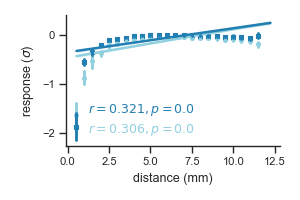

In [20]:
# short_dist = df_dist['distance'] < 5
x_bins = np.arange(0, 12, 0.5)
corr_plot(df_dist, x="distance", y="erp", x_bins=x_bins)
plt.xlabel('distance (mm)')
plt.ylabel('response ($\\sigma$)')


b r= -0.108 p= 0.0 n = 7680
a r= -0.074 p= 0.0 n = 7680


Text(-1.458333333333334, 0.5, 'response ratio')

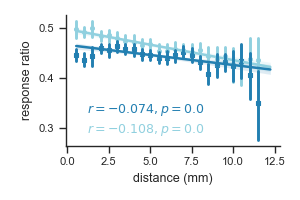

In [21]:
# correlate electrode distance to fraction of trials with response
corr_plot(df_dist, x="distance", y="resp", x_bins=x_bins)
plt.xlabel('distance (mm)')
plt.ylabel('response ratio')


b r= -0.297 p= 0.0 n = 7680
a r= -0.445 p= 0.0 n = 7680


Text(4.791666666666666, 0.5, 'selectivity')

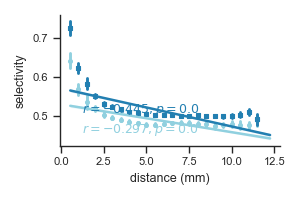

In [22]:
# correlate electrode distance to selectivity
corr_plot(df_dist, x="distance", y="auc", x_bins=x_bins)
plt.xlabel('distance (mm)')
plt.ylabel('selectivity')